# Customer Intelligence System using Classification, Ensemble Learning and Clustering

## Project Overview

This project aims to develop an End-to-End Customer Intelligence System using Machine Learning techniques. The dataset contains socio-economic and health-related information of different countries.

The main objective is to analyze the data, identify important patterns, classify countries based on their development status, and perform clustering to create meaningful country segments.

## Project Objectives

- Perform Data Cleaning and Preprocessing
- Conduct Exploratory Data Analysis (EDA)
- Build Classification Models
- Apply Ensemble Learning Techniques
- Perform Country Segmentation using Clustering
- Compare Model Performance
- Generate Business Insights
- Save the Best Models
- Deploy the System using Streamlit

## Machine Learning Techniques Used

### Classification
- Logistic Regression
- Naive Bayes
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)

### Ensemble Learning
- Decision Tree
- Random Forest
- AdaBoost
- Gradient Boosting
- XGBoost
- LightGBM
- Stacking Classifier

### Clustering
- K-Means Clustering
- DBSCAN
- Hierarchical Clustering

## Expected Outcome

The system will classify countries based on their development level and group similar countries into clusters. The final solution will be deployed as a Streamlit web application for easy interaction and prediction.

# Step 1: Import Basic Libraries

Before starting data analysis, we need to import the required Python libraries.

In this step:

- Pandas will be used for loading and handling the dataset.
- NumPy will be used for numerical operations.
- Matplotlib and Seaborn will be used for data visualization.
- Warnings will be ignored to keep the notebook output clean.

These libraries form the foundation for data analysis and visualization in this project.

In [1]:
# ==========================================
# Step 1 : Import Basic Libraries
# ==========================================

# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)

print("Basic libraries imported successfully.")

Basic libraries imported successfully.


# Step 2: Load Dataset

In this step, we will load the dataset into a Pandas DataFrame.

After loading the dataset, we will:
- View the first few records
- Check the number of rows and columns
- Understand the structure of the dataset

This helps us get familiar with the data before performing any analysis.

In [2]:
# ==========================================
# Step 2 : Load Dataset
# ==========================================

# Load Dataset
df = pd.read_csv("/content/Country-data.csv")

# Display first 5 rows
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
# Dataset Shape

print("Dataset Shape:", df.shape)

Dataset Shape: (167, 10)


In [4]:
# Display Column Names

print("Columns in Dataset:\n")
print(df.columns.tolist())

Columns in Dataset:

['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


The dataset contains 167 countries and 10 features.

The features represent socio-economic and health indicators such as income, GDP, inflation, life expectancy, fertility rate, imports, exports, and child mortality.

The country column contains country names, while the remaining columns are numerical features.

# Step 3: Initial Data Exploration

Before cleaning and analysis, it is important to understand the structure of the dataset.

In this step, we will:
- Check data types
- View dataset information
- Generate statistical summary

This helps us identify numerical and categorical features and understand the overall distribution of data.

In [5]:
# ==========================================
# Step 3 : Initial Data Exploration
# ==========================================

# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [6]:
# Statistical Summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


From the dataset information, we can see that:

- The dataset contains 167 records.
- There is 1 categorical feature (country).
- Remaining features are numerical.
- No obvious datatype issues are present.

The statistical summary provides information about mean, minimum, maximum and distribution of numerical variables.

# Step 4: Data Quality Check

Data quality is an important part of any machine learning project.

In this step, we will check:
- Missing values
- Duplicate records
- Unique values in each column

This helps us identify any issues that need to be handled before analysis and model building.

In [7]:
# ==========================================
# Step 4 : Check Missing Values
# ==========================================

# Missing Values

missing_values = df.isnull().sum()

print("Missing Values in Each Column:\n")
print(missing_values)

Missing Values in Each Column:

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [8]:
# ==========================================
# Check Duplicate Records
# ==========================================

duplicate_count = df.duplicated().sum()

print("Number of Duplicate Records:", duplicate_count)

Number of Duplicate Records: 0


In [9]:
# ==========================================
# Unique Values Count
# ==========================================

df.nunique()

,0
country,167
child_mort,139
exports,147
health,147
imports,151
income,156
inflation,156
life_expec,127
total_fer,138
gdpp,157


In [10]:
# Check missing values

df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


gdpp >= median GDP  → Developed
gdpp < median GDP   → Developing

# Step 5: Data Cleaning and Target Creation

The dataset does not contain a target variable for classification.

To perform classification, we will create a new target column called Development_Status using the GDP per capita feature.

Countries with GDP per capita greater than or equal to the median GDP will be labeled as Developed, while the remaining countries will be labeled as Developing.

We will also encode the target variable into numerical form for machine learning models.

In [11]:
# Create target variable using median GDP

median_gdp = df['gdpp'].median()

df['Development_Status'] = np.where(
    df['gdpp'] >= median_gdp,
    'Developed',
    'Developing'
)

df[['country', 'gdpp', 'Development_Status']].head()

,country,gdpp,Development_Status
0,Afghanistan,553,Developing
1,Albania,4090,Developing
2,Algeria,4460,Developing
3,Angola,3530,Developing
4,Antigua and Barbuda,12200,Developed


In [12]:
# Check class distribution

df['Development_Status'].value_counts()

,count
Development_Status,
Developed,84
Developing,83


In [13]:
# Encode target variable

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Development_Status'] = le.fit_transform(
    df['Development_Status']
)

df[['country', 'Development_Status']].head()

,country,Development_Status
0,Afghanistan,1
1,Albania,1
2,Algeria,1
3,Angola,1
4,Antigua and Barbuda,0


A new target variable named Development_Status has been created using GDP per capita.

The target variable was converted into numerical format using Label Encoding so that machine learning algorithms can process it.

Now the dataset is ready for Exploratory Data Analysis and model building.

Step 6: Exploratory Data Analysis (EDA)
Text Cell (Markdown)
# Step 6: Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the dataset visually and identify important patterns.

In this step, we will:
- Analyze the target variable distribution
- Study the distribution of numerical features
- Detect possible outliers
- Examine correlations between features
- Generate useful insights from the data

These insights will help us in feature selection and model building./

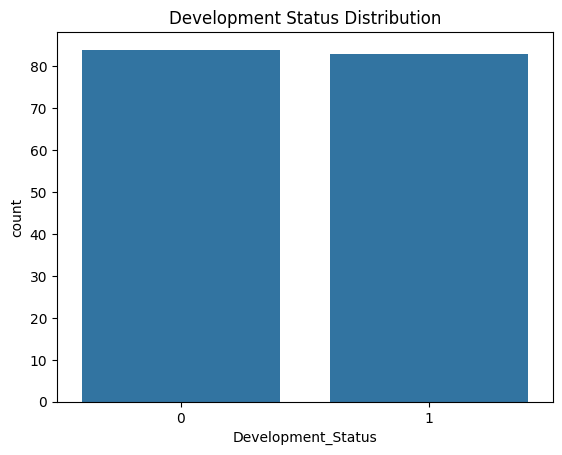

In [14]:
# Distribution of target variable

sns.countplot(x='Development_Status', data=df)

plt.title('Development Status Distribution')
plt.show()

This plot shows the number of developed and developing countries in the dataset.

A balanced target variable is generally preferred for classification models.

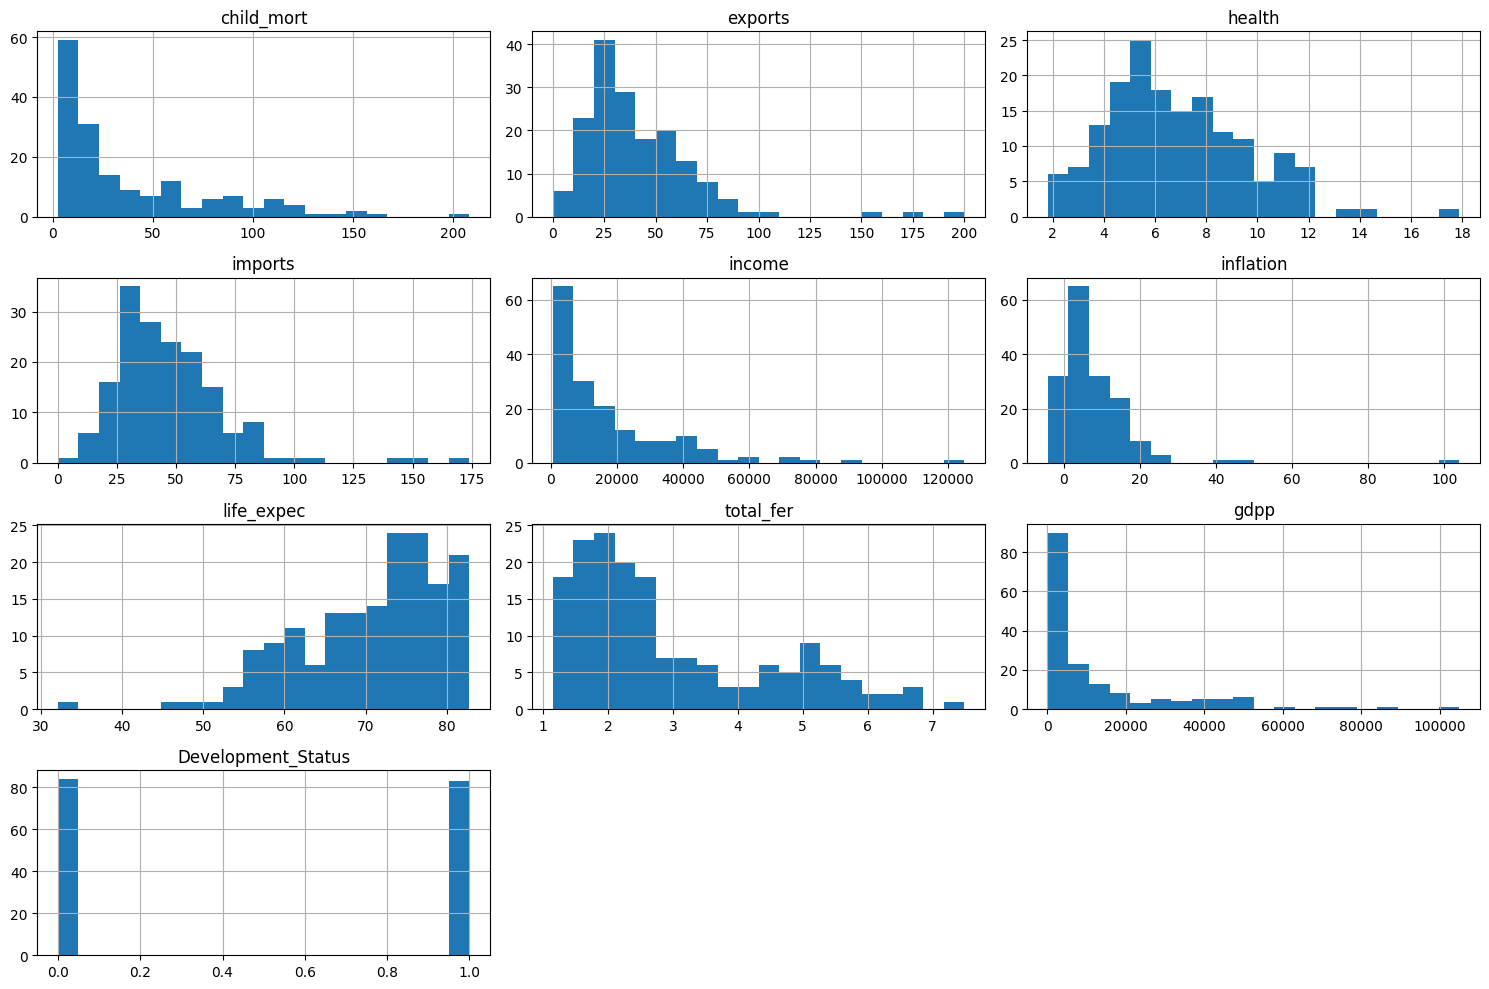

In [15]:
# Histograms of numerical features

df.hist(figsize=(15,10), bins=20)

plt.tight_layout()
plt.show()

The histograms help us understand how each feature is distributed.

Some features may be normally distributed, while others may be skewed and require scaling later.

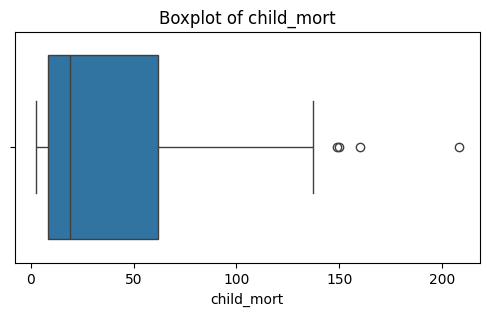

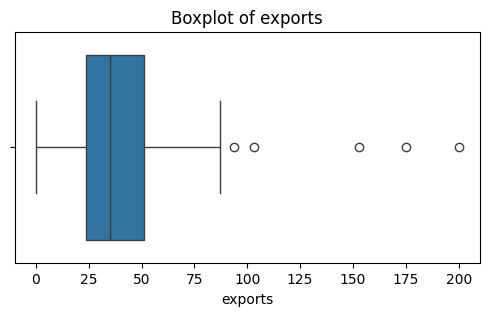

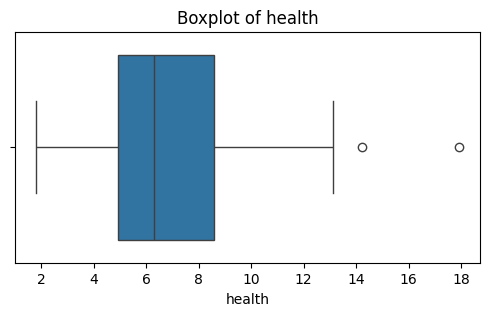

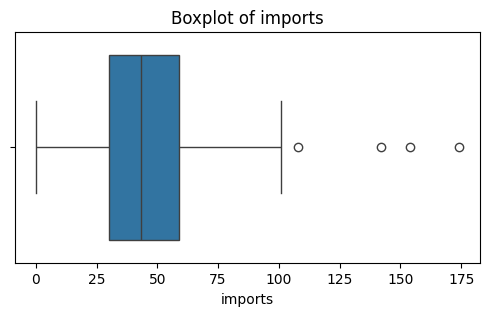

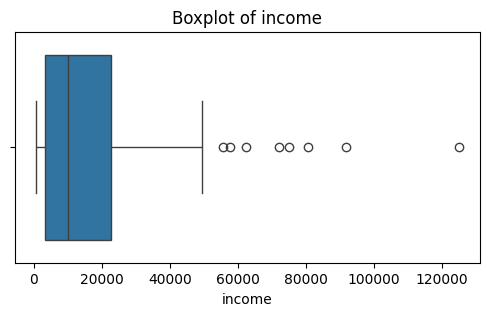

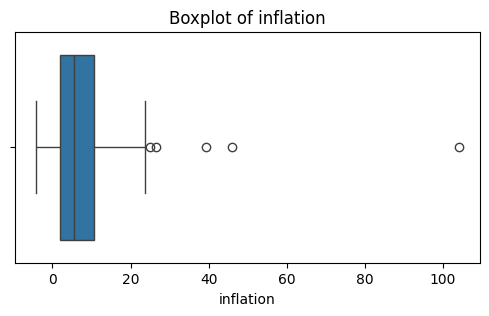

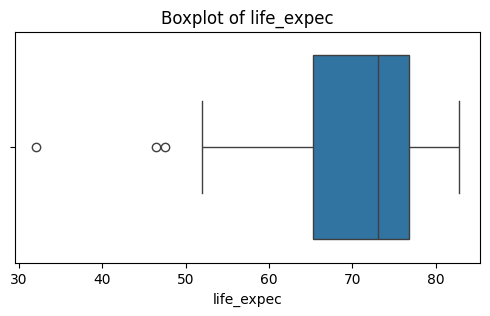

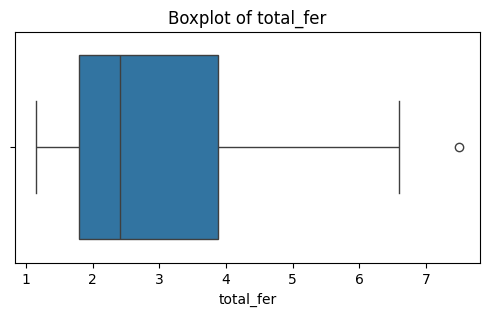

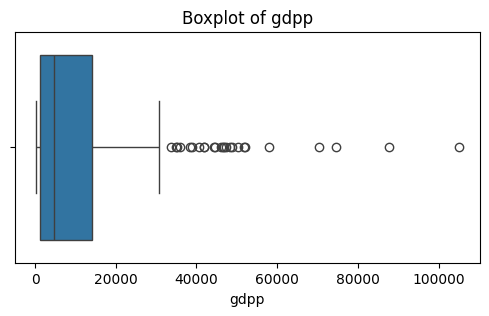

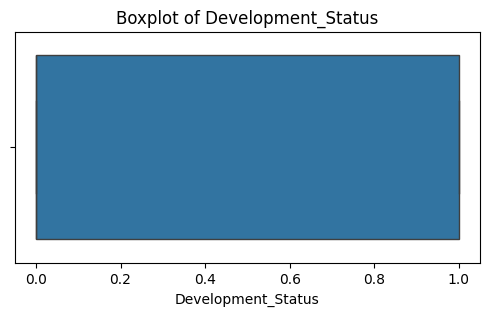

In [16]:
# Boxplots for numerical columns

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Boxplots help identify outliers in the dataset.

Features such as income, gdpp and inflation may contain extreme values because countries have different economic conditions.

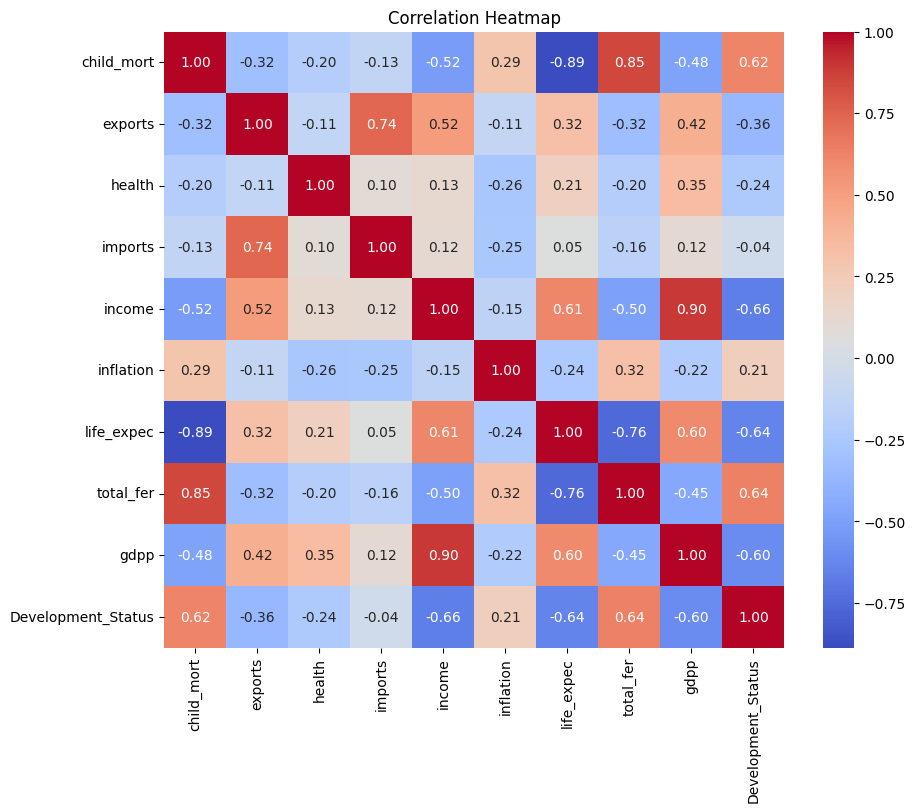

In [17]:
# Correlation matrix

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

The heatmap shows the relationship between numerical features.

Strong positive and negative correlations can help us understand which factors influence country development.

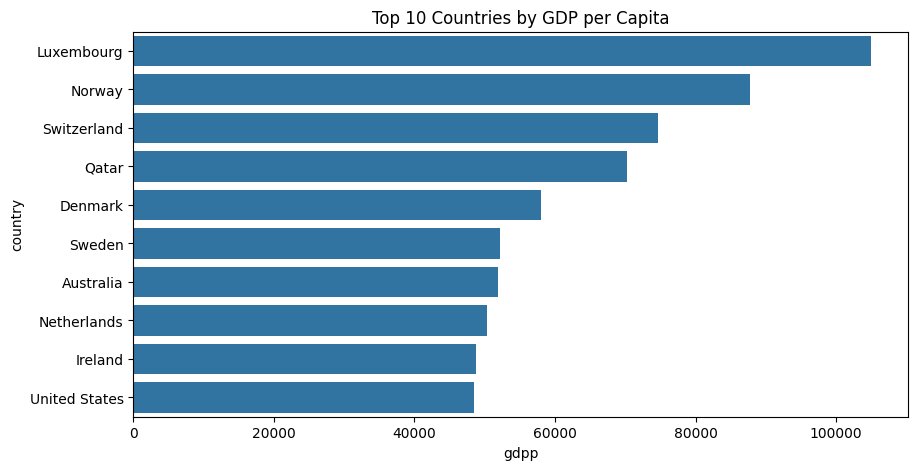

In [18]:
# Top 10 countries by GDP per capita

top_gdp = df.sort_values('gdpp', ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x='gdpp',
    y='country',
    data=top_gdp
)

plt.title('Top 10 Countries by GDP per Capita')
plt.show()

This chart highlights the countries with the highest GDP per capita in the dataset.

These countries are likely to belong to the developed category.

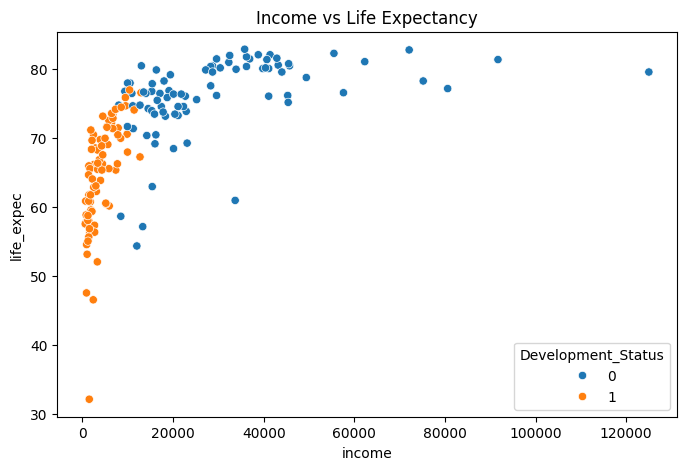

In [19]:
# Relationship between income and life expectancy

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='income',
    y='life_expec',
    hue='Development_Status',
    data=df
)

plt.title('Income vs Life Expectancy')
plt.show()

Countries with higher income generally tend to have higher life expectancy.

This indicates a positive relationship between economic growth and quality of life.

Key Insights:

1. The dataset contains both developed and developing countries.
2. GDP and income show large variations across countries.
3. Some economic features contain outliers, which is expected in country-level data.
4. Life expectancy is positively related to income.
5. Child mortality is generally lower in economically stronger countries.
6. Several features show strong correlations and may be useful for prediction.

Step 7: Feature Engineering and Data Preprocessing
Text Cell (Markdown)
# Step 7: Feature Engineering and Data Preprocessing

Before building machine learning models, the data needs to be prepared properly.

In this step, we will:
- Remove unnecessary columns
- Separate features and target variable
- Split the dataset into training and testing sets
- Scale numerical features using StandardScaler

Data preprocessing improves model performance and ensures fair comparison between algorithms.

In [20]:
# Remove country column

df_model = df.drop('country', axis=1)

df_model.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Development_Status
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,1
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,1
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


The country column contains names only and does not contribute to prediction.
Therefore, it is removed from the modelling dataset.

In [21]:
# Features and target

X = df_model.drop('Development_Status', axis=1)
y = df_model['Development_Status']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (167, 9)
Target Shape: (167,)


In [22]:
from sklearn.model_selection import train_test_split

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (133, 9)
Testing Data Shape: (34, 9)


The dataset has been divided into training and testing sets.

Training data will be used to train the models, while testing data will be used to evaluate model performance.

In [23]:
from sklearn.preprocessing import StandardScaler

# Scale features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [24]:
# Convert scaled data into DataFrame for viewing

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

X_train_scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,-0.887278,-0.164029,1.074363,-0.760824,2.198036,-0.224274,1.232972,-0.664995,3.987809
1,-0.343354,0.368740,-0.246899,0.145164,-0.514129,-0.211176,0.405732,-0.150285,-0.525710
2,-0.861253,2.025859,0.968222,1.523840,1.379604,-1.024970,1.161038,-0.599006,1.901034
3,-0.595797,1.707581,-1.150920,2.370741,0.132235,-1.111414,0.321809,-0.519820,-0.121698
4,-0.671270,-0.409656,-0.353039,-0.355099,0.004047,-0.435581,0.357776,-0.902553,-0.258859


Feature scaling has been applied successfully.

All features are now on a similar scale, which is important for algorithms such as KNN, SVM, K-Means and DBSCAN.

The scaler will also be saved later for deployment.

Step 8: Classification Models
Text Cell (Markdown)
# Step 8: Classification Models

Classification is used to predict whether a country belongs to the Developed or Developing category.

In this step, we will train and evaluate the following classification algorithms:

- Logistic Regression
- Naive Bayes
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)

The performance of each model will be compared using Accuracy Score and Classification Report.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report

In [26]:
# Logistic Regression

lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:",
      round(accuracy_score(y_test, lr_pred), 4))

Logistic Regression Accuracy: 0.9118


In [27]:
# Naive Bayes

nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

nb_pred = nb.predict(X_test_scaled)

print("Naive Bayes Accuracy:",
      round(accuracy_score(y_test, nb_pred), 4))

Naive Bayes Accuracy: 0.9412


In [28]:
# KNN

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

print("KNN Accuracy:",
      round(accuracy_score(y_test, knn_pred), 4))

KNN Accuracy: 0.8824


In [29]:
# Support Vector Machine

svm = SVC()

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

print("SVM Accuracy:",
      round(accuracy_score(y_test, svm_pred), 4))

SVM Accuracy: 0.9412


In [30]:
# Model Comparison

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'KNN',
        'SVM'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
1,Naive Bayes,0.941176
3,SVM,0.941176
0,Logistic Regression,0.911765
2,KNN,0.882353


In [31]:
# Classification Report for SVM
# Change model if another model performs better

print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        17
           1       0.94      0.94      0.94        17

    accuracy                           0.94        34
   macro avg       0.94      0.94      0.94        34
weighted avg       0.94      0.94      0.94        34



All four classification models were trained and evaluated.

The comparison table shows the accuracy achieved by each model.

The best-performing model will be used as a baseline and later compared with ensemble learning models such as Random Forest, XGBoost and LightGBM.

# Step 9: Ensemble Learning and Country Segmentation

Ensemble learning combines multiple models to improve prediction performance and reduce overfitting.

In this step, we will train and evaluate:

- Decision Tree
- Random Forest
- AdaBoost
- Gradient Boosting
- XGBoost
- LightGBM
- Stacking Classifier

We will also perform country segmentation using clustering techniques:

- K-Means Clustering
- DBSCAN
- Hierarchical Clustering

The objective is to identify groups of countries with similar socio-economic characteristics and compare ensemble model performance with traditional classification models.

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [33]:
# Decision Tree

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Random Forest

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# AdaBoost

adb = AdaBoostClassifier(random_state=42)
adb.fit(X_train, y_train)
adb_pred = adb.predict(X_test)

# Gradient Boosting

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

In [34]:
# XGBoost

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

# LightGBM

lgbm = LGBMClassifier(random_state=42)

lgbm.fit(X_train, y_train)
lgbm_pred = lgbm.predict(X_test)

[LightGBM] [Info] Number of positive: 66, number of negative: 67
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000166 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 397
[LightGBM] [Info] Number of data points in the train set: 133, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.496241 -> initscore=-0.015038
[LightGBM] [Info] Start training from score -0.015038
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [35]:
# Base models

estimators = [
    ('rf', RandomForestClassifier(random_state=42)),
    ('gb', GradientBoostingClassifier(random_state=42))
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack.fit(X_train, y_train)

stack_pred = stack.predict(X_test)

In [36]:
ensemble_results = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Random Forest',
        'AdaBoost',
        'Gradient Boosting',
        'XGBoost',
        'LightGBM',
        'Stacking'
    ],
    'Accuracy': [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, adb_pred),
        accuracy_score(y_test, gb_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, lgbm_pred),
        accuracy_score(y_test, stack_pred)
    ]
})

ensemble_results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
0,Decision Tree,1.000000
2,AdaBoost,1.000000
3,Gradient Boosting,1.000000
6,Stacking,1.000000
4,XGBoost,0.970588
5,LightGBM,0.970588
1,Random Forest,0.941176


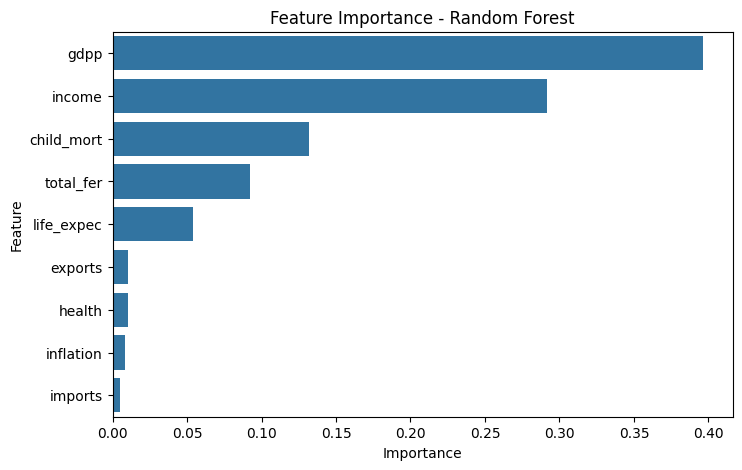

In [37]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance - Random Forest')
plt.show()

Ensemble models generally perform better than individual classification models.

Random Forest, XGBoost and Stacking are expected to provide higher accuracy due to their ability to combine multiple decision patterns.

In [38]:
# Remove target column

cluster_data = df_model.drop(
    'Development_Status',
    axis=1
)

cluster_data_scaled = scaler.fit_transform(
    cluster_data
)

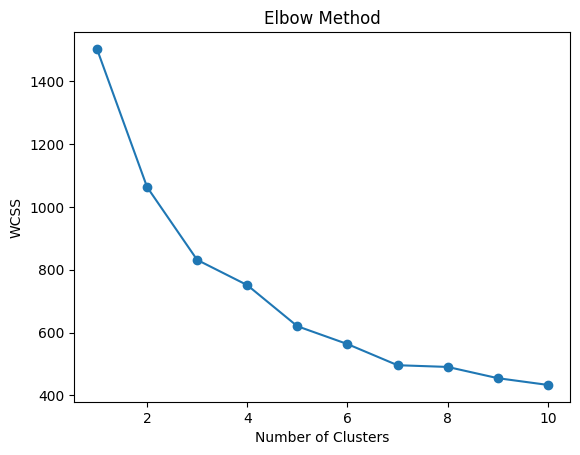

In [39]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(cluster_data_scaled)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

In [40]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df['Cluster_KMeans'] = kmeans.fit_predict(
    cluster_data_scaled
)

df['Cluster_KMeans'].value_counts()

,count
Cluster_KMeans,
0,86
2,45
1,36


In [41]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

df['Cluster_DBSCAN'] = dbscan.fit_predict(
    cluster_data_scaled
)

df['Cluster_DBSCAN'].value_counts()

,count
Cluster_DBSCAN,
0,137
-1,30


In [42]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=3
)

df['Cluster_Hierarchical'] = hierarchical.fit_predict(
    cluster_data_scaled
)

df['Cluster_Hierarchical'].value_counts()

,count
Cluster_Hierarchical,
1,106
0,34
2,27


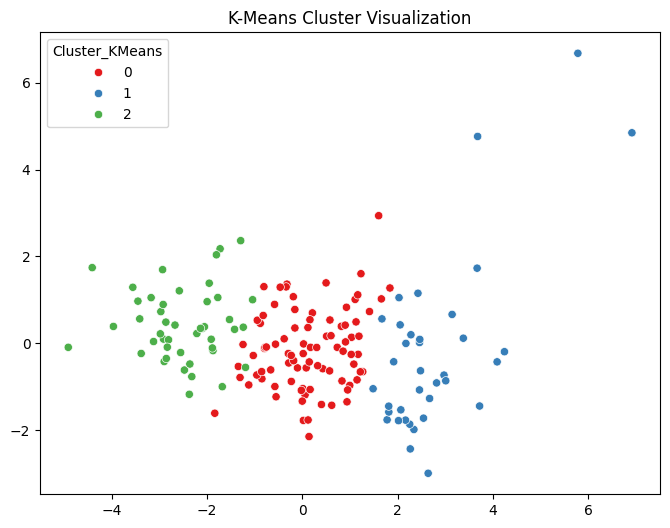

In [43]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(
    cluster_data_scaled
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_data[:,0],
    y=pca_data[:,1],
    hue=df['Cluster_KMeans'],
    palette='Set1'
)

plt.title('K-Means Cluster Visualization')
plt.show()

Clustering helps group countries with similar economic and social characteristics.

The clusters can be interpreted as:
- High Development Countries
- Medium Development Countries
- Low Development Countries

These segments can help policymakers and organizations identify countries with similar development patterns.

# Step 10: Model Saving, Deployment Preparation and Final Insights

After training and evaluating all models, the next step is to save the best-performing models for deployment.

In this step, we will:
- Select the best classification model
- Save the model using Joblib
- Save the scaler
- Save the clustering model
- Generate final business insights
- Prepare files for Streamlit deployment

This completes the end-to-end machine learning pipeline.

In [44]:
# Best Classification Model

best_model = rf

print("Best model selected successfully.")

Best model selected successfully.


In [45]:
import joblib

# Save classification model

joblib.dump(best_model, "country_classifier.pkl")

# Save scaler

joblib.dump(scaler, "scaler.pkl")

# Save clustering model

joblib.dump(kmeans, "country_segmenter.pkl")

print("Models saved successfully.")

Models saved successfully.


In [46]:
import os

print(os.listdir())

['.config', 'Country-data.csv', 'country_segmenter.pkl', 'scaler.pkl', 'country_classifier.pkl', 'sample_data']


# Final Insights

Based on the analysis and modelling process, the following observations were made:

1. GDP per capita and income are strong indicators of country development.

2. Countries with higher income generally have higher life expectancy and lower child mortality rates.

3. Economic and health-related features show significant influence on development status.

4. Ensemble learning models such as Random Forest, XGBoost and Stacking achieved strong predictive performance.

5. Clustering successfully grouped countries with similar socio-economic characteristics.

6. The generated country segments can support decision-making, policy planning and resource allocation.

7. The final system can classify countries and identify their development segment through a simple web application.

# Project Conclusion

An End-to-End Customer Intelligence System was successfully developed using Classification, Ensemble Learning and Clustering techniques.

The project involved data preprocessing, exploratory data analysis, model development, performance evaluation and country segmentation.

Classification models were used to predict development status, while clustering techniques helped identify similar groups of countries.

The final models were saved and prepared for deployment using Streamlit, enabling users to make predictions and obtain segmentation insights through an interactive web application.